In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
df= pd.read_csv("E:/Classification_ML_Project/data/raw/netflix_customer_churn.csv")
#Show Sample of Dataset

df=df.drop(columns='customer_id')

In [2]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


In [3]:
#Show info of each dataset columns
df.info()
#Show the data distribution for each columns 
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   str    
 2   subscription_type       5000 non-null   str    
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   str    
 6   device                  5000 non-null   str    
 7   monthly_fee             5000 non-null   float64
 8   churned                 5000 non-null   int64  
 9   payment_method          5000 non-null   str    
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(6)
memory usage: 507.9 KB


,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


<function matplotlib.pyplot.show(close=None, block=None)>

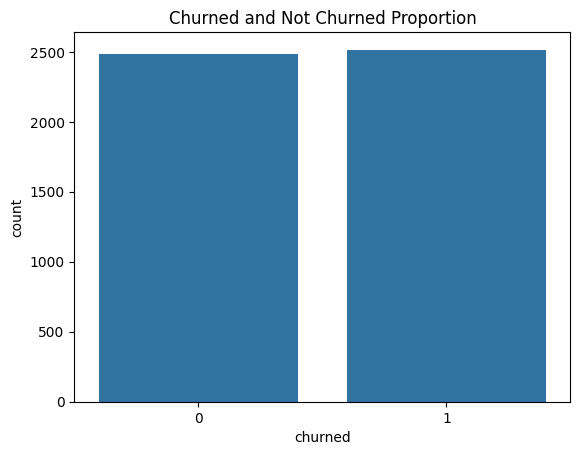

In [4]:
#Show Label Proportion
df['churned'].value_counts(normalize=True)
#Visualize the proportion
sns.countplot(x='churned',data=df)
plt.title('Churned and Not Churned Proportion')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

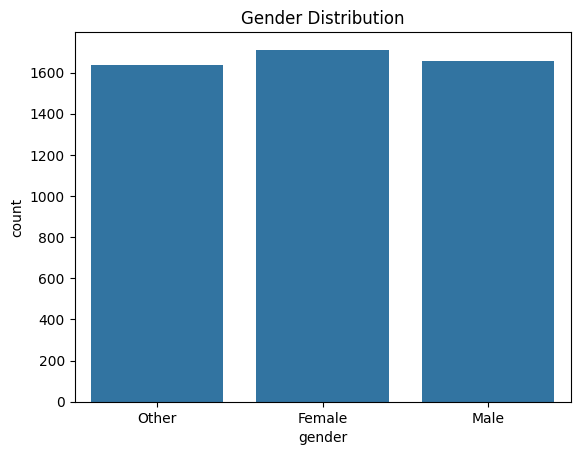

In [5]:
#Show Label Proportion
df['gender'].value_counts(normalize=True)
#Visualize the proportion
sns.countplot(x='gender',data=df)
plt.title('Gender Distribution')
plt.show

In [6]:
#Show is there any missing values
miss_val=df.isnull().sum()
miss_val[miss_val > 0]

Series([], dtype: int64)

In [7]:
#Show is there any duplicated data
df.duplicated().sum()

np.int64(0)

In [8]:
#Split Data Type
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object','str']).columns

In [9]:
df[num_cols].describe()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,11.649450,30.089800,13.683400,0.503000,3.024400,0.874800
std,15.501128,12.014654,17.536078,3.692062,0.500041,1.415841,2.619824
min,18.000000,0.010000,0.000000,8.990000,0.000000,1.000000,0.000000
25%,30.000000,3.337500,15.000000,8.990000,0.000000,2.000000,0.110000
50%,44.000000,8.000000,30.000000,13.990000,1.000000,3.000000,0.290000
75%,58.000000,16.030000,45.000000,17.990000,1.000000,4.000000,0.720000
max,70.000000,110.400000,60.000000,17.990000,1.000000,5.000000,98.420000


BoxPlot To see is there an outliers with IQR Concept


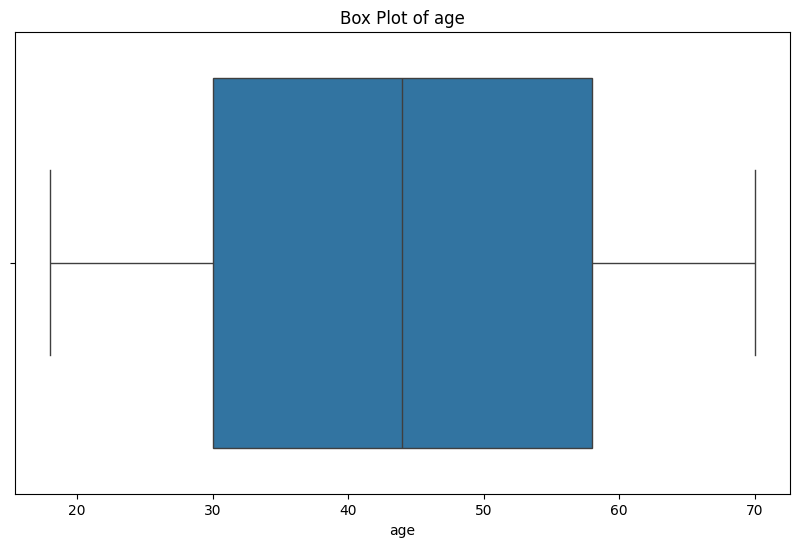

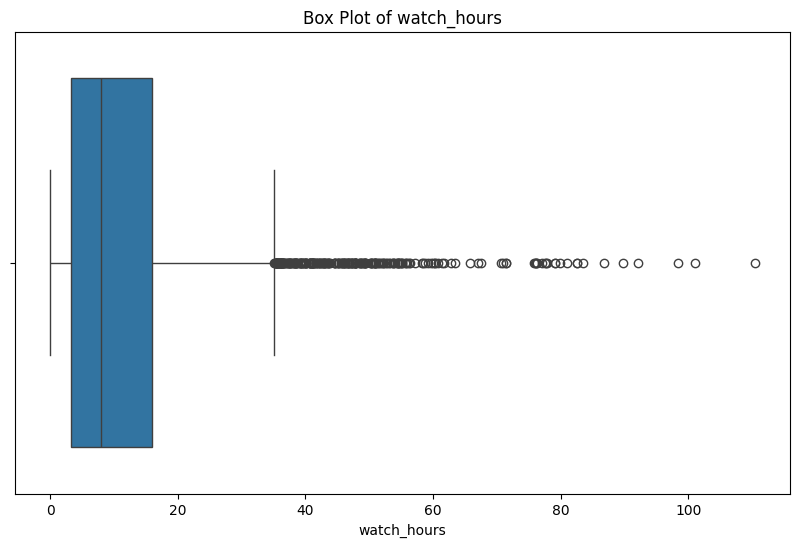

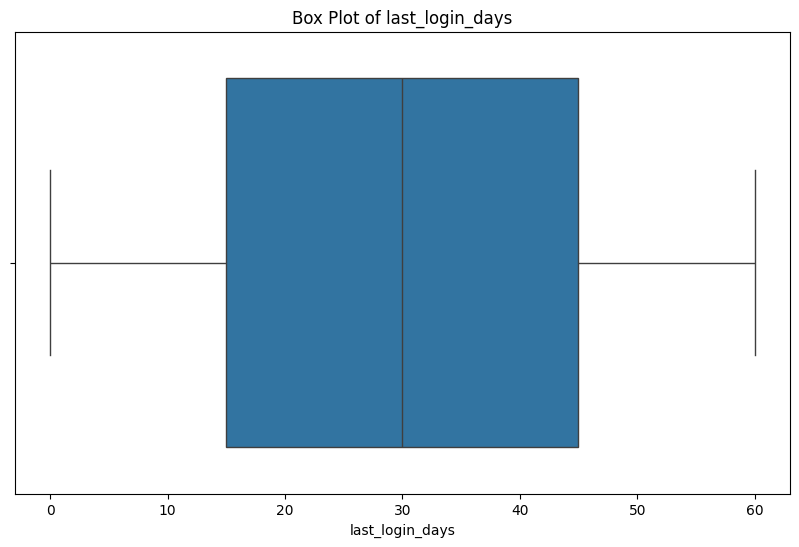

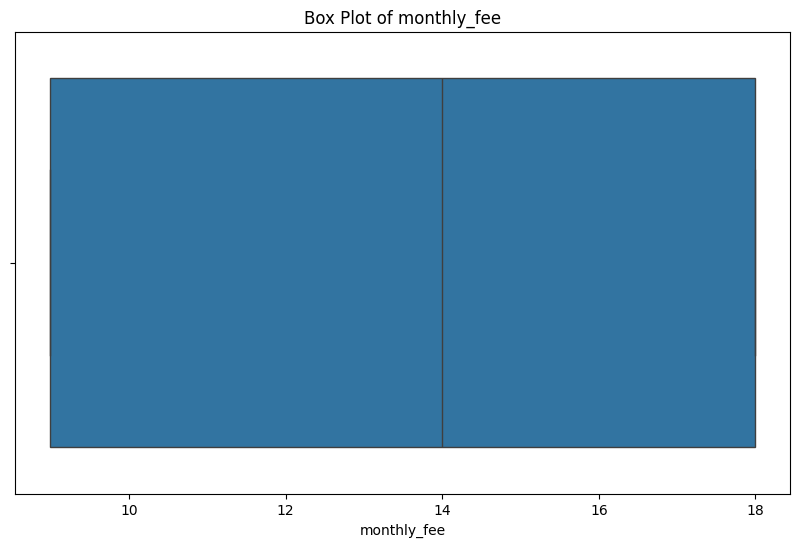

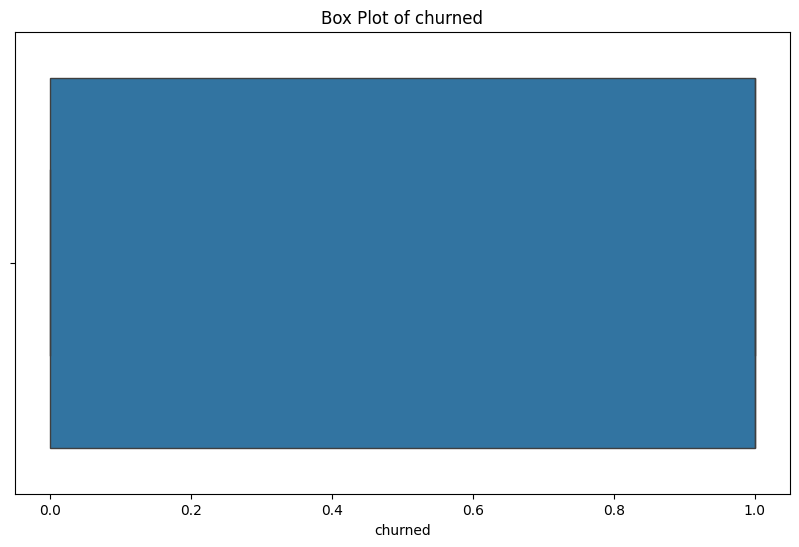

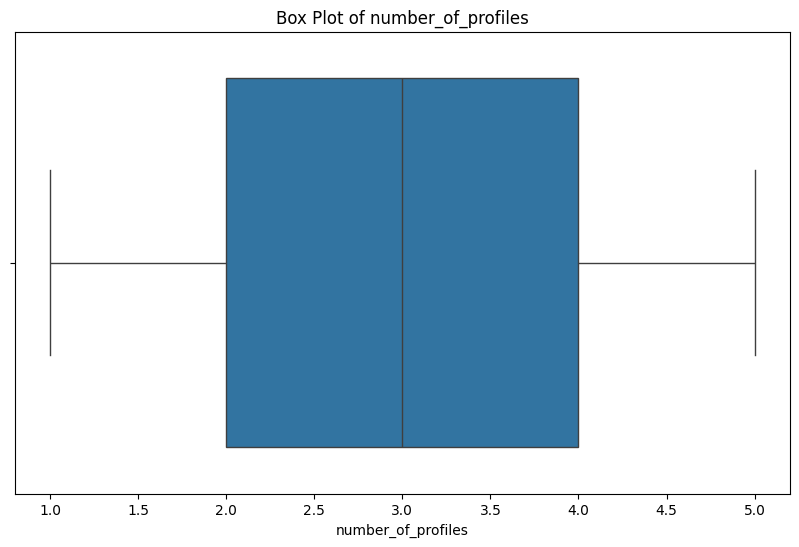

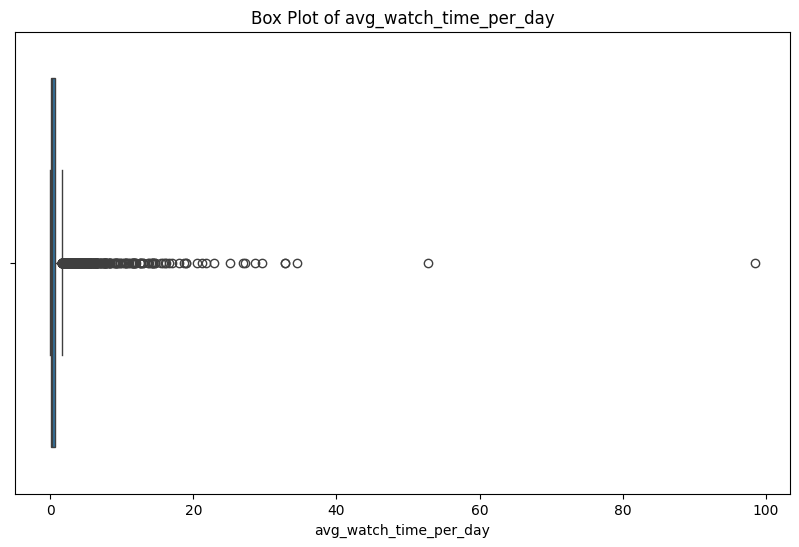

HistPlot to know data context by the data distribution 


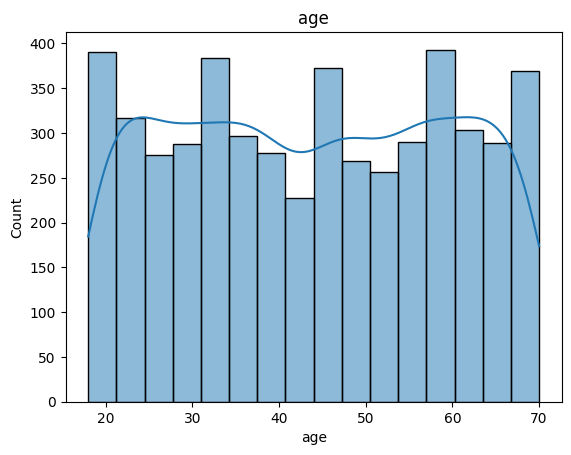

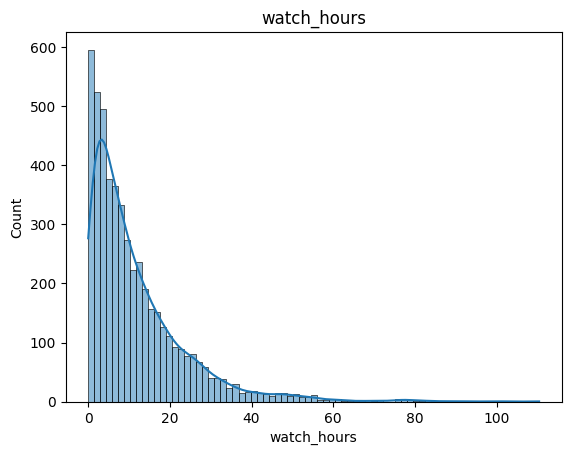

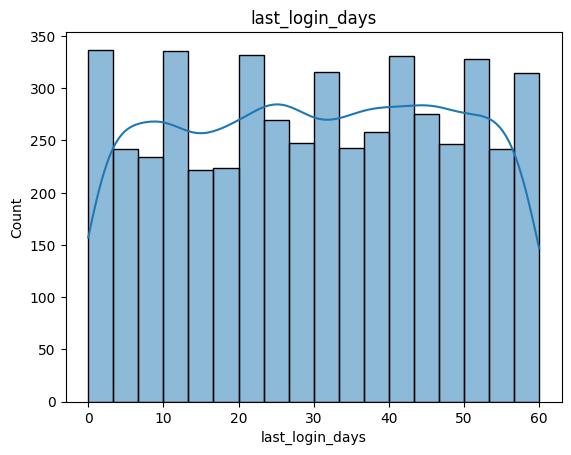

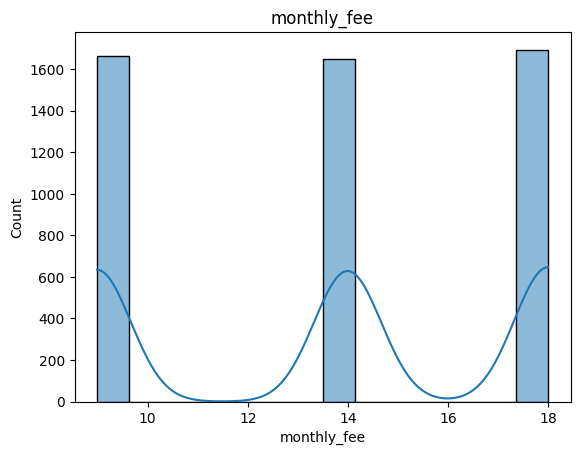

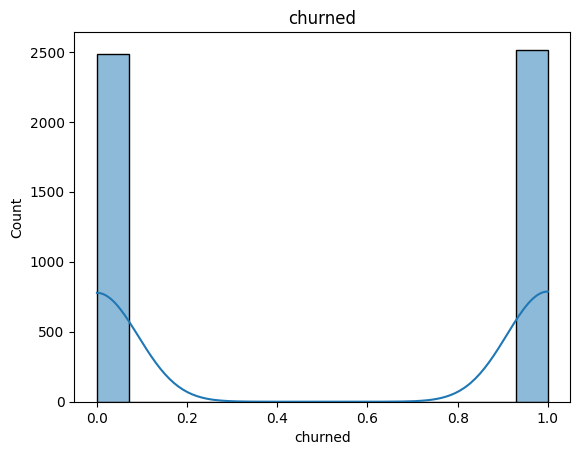

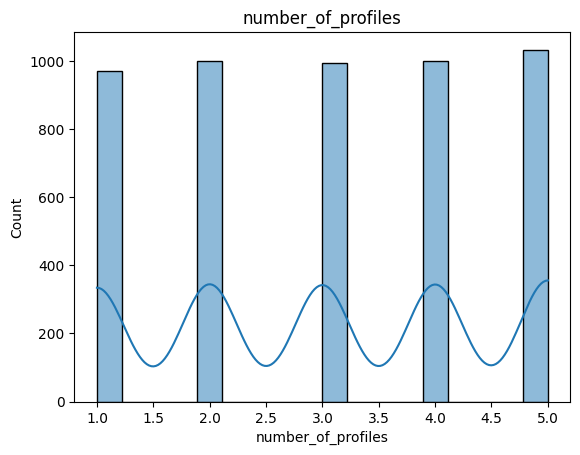

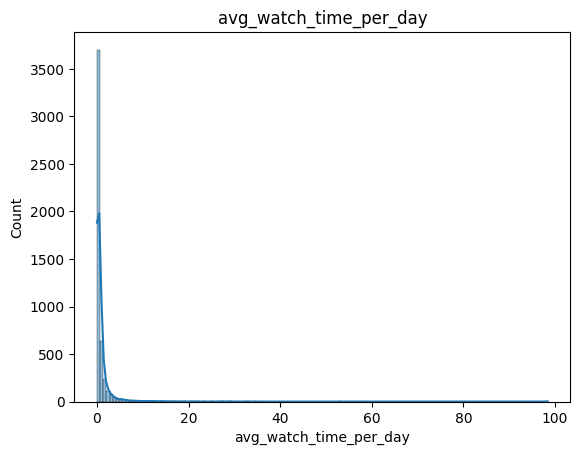

In [10]:
#Show is thare any outliers
print('BoxPlot To see is there an outliers with IQR Concept')
for feature in num_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
    plt.show()

print('HistPlot to know data context by the data distribution ')
for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

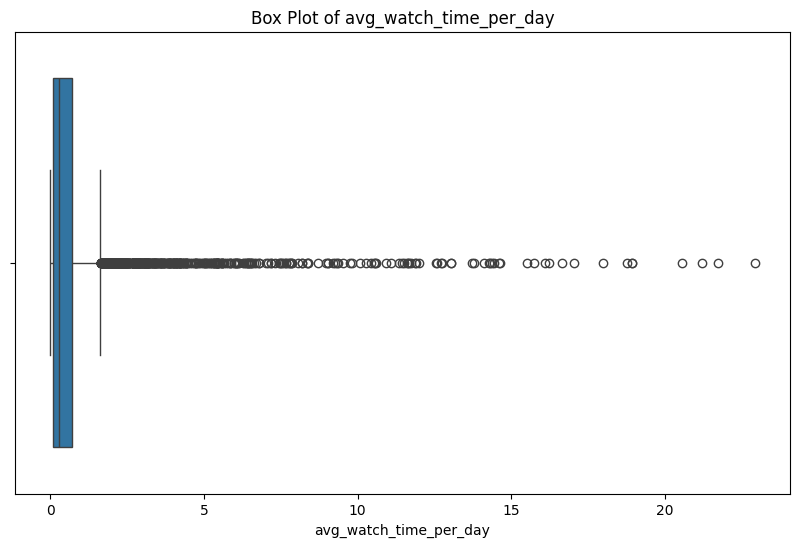

In [11]:
#delete unreasonable data
#Delete avg watch time per day which more than 24 hours
df = df[df["avg_watch_time_per_day"] <= 24]

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['avg_watch_time_per_day'])
plt.title(f'Box Plot of avg_watch_time_per_day')
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler,LabelEncoder

scaler=StandardScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])

lb_encoder=LabelEncoder()
df_lancoder= pd.DataFrame(df)

for col in cat_cols:
    df_lancoder[col]=lb_encoder.fit_transform(df[col])
    

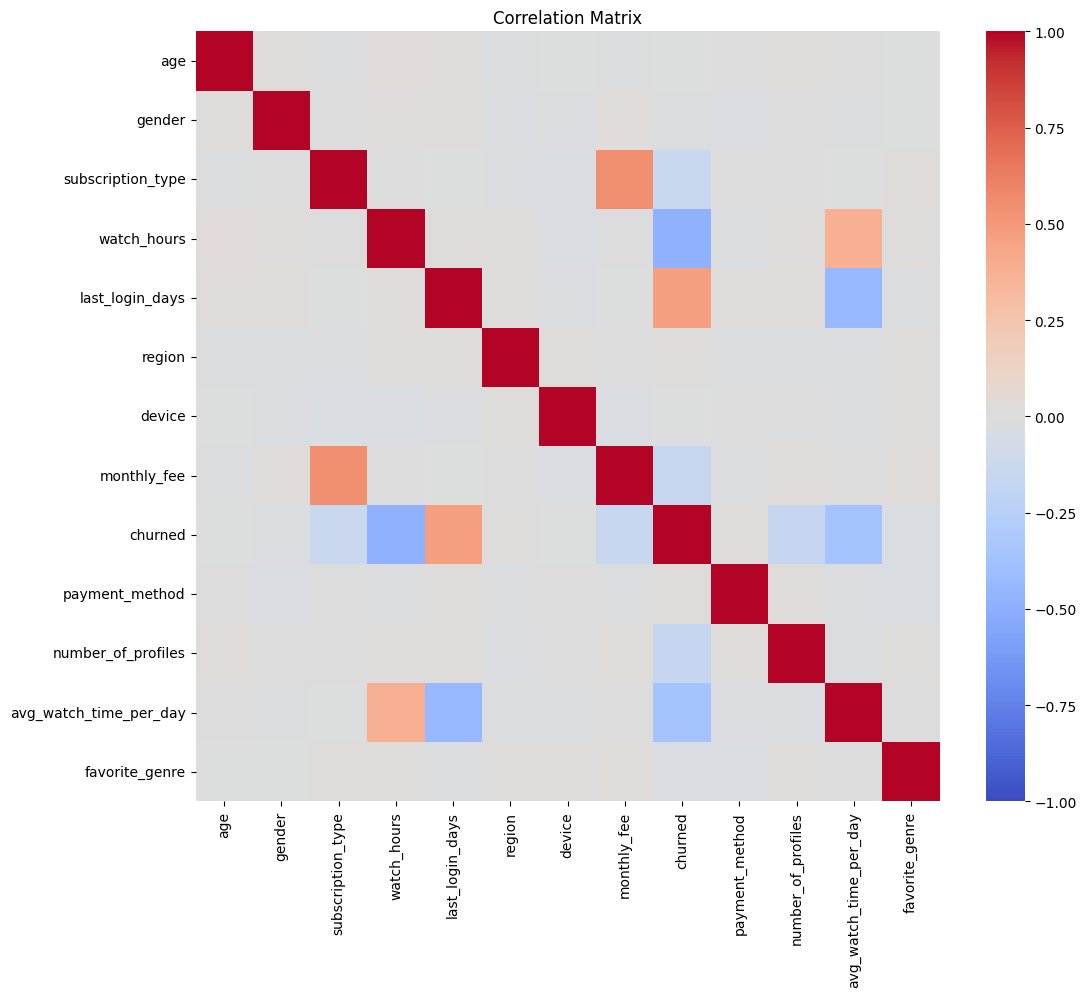

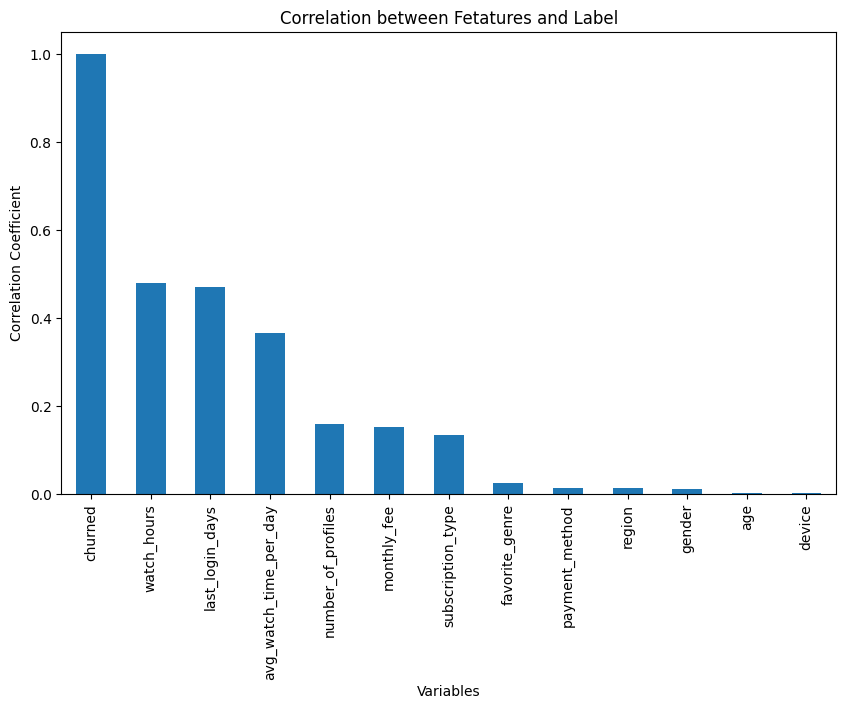

In [ ]:
# Heatmap Visualization of label and fetatures correlation
plt.figure(figsize=(12, 10))
correlation_matrix = df_lancoder.corr()
 
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

# Box Plot Visualization of label and fetatures correlation
target_corr=df_lancoder.corr()['churned']
target_corr_sorted= target_corr.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
target_corr_sorted.plot(kind='bar')
plt.title('Correlation between Fetatures and Label')
plt.xlabel('Variables')
plt.ylabel('Correlation Coefficient')
plt.show()